# Módulo 3: Limpieza y transformación de datos

## Selección de características: Varianzas y correlaciones temporales

#### Objetivo

- Conceptos
  - Entender lo que implica una varianza y una correlación.
- Implicaciones
  - Varianza
    - Entender por qué una variable con nula varianza no es útil a la hora de modelar.
  - Correlación
    - Entender por qué una variable muy correlacionada con otra no dara información extra.
    - Entender por qué una variable correlacionada con la variable de respuesta servirá mucho para estimar.
- Definir una metodología que nos permita elegir variables (correlación) y otro que nos permita remover variables (varianza).

#### Actividad 1 guiada:

- Definir una metodología que nos permita elegir variables (correlación) y otro que nos permita remover variables (varianza).
- Lee el archivo `actividad2b_6_1.csv`

#### Actividad 2 autónoma:

- Tomar el dataset `actividad2c_6_1.csv` de la plataforma y:
  - Analizar distribuciones de cada una de las variables.
    - Graficar histograma por variable (te recomiendo graficarlos en una cuadrícula para que sea más fácil analizarlos. Te puedes ayudar de algo así: https://stackoverflow.com/questions/29530355/plotting-multiple-histograms-in-grid.
    - El punto anterior no es obligatorio pero te ayudará a hacer las conclusiones del siguiente.
    - Escribe: ¿Qué observas hasta aquí? ¿Hay variables que puedas descartar desde ahorita? ¿Por qué?
    - Escribe: ¿Hay variables que parezcan candidatas a seleccionarse desde aquí? ¿Por qué?
  - Grafica un mapa de calor de correlaciones (correlation heatmap).
    - Escribe: ¿Qué observas hasta aquí? ¿Hay variables que puedas descartar desde ahorita? ¿Por qué?
    - Escribe: ¿Hay variables que parezcan candidatas a seleccionarse desde aquí? ¿Por qué?
  - Selecciona variables.
    - Aplicando los conocimientos adquiridos en clase:
      - Utiliza el método de varianza y de correlación para seleccionar variables.
      - Selecciona un set de variables por cada uno de los métodos y responde:
        - ¿Por qué seleccionaste ese set?
      - Haz quintiles por cada una de tus variables seleccionadas en cada uno de los métodos y responde:
        - Según esta gráfica, ¿tiene sentido haber hecho esta selección? ¿Cuál método parece haber seleccionado mejores variables? ¿por qué?


## Conceptos básicos

### Varianza

En sesiones anteriores se ha abordado ya el tema de la desviación estándar el cual en realidad es la raíz cuadrada de la **varianza**.

La varianza entonces, se define de la siguiente manera:

$$ V = \frac{1}{n}\sum\_{i=1}^n(x_i - \bar{x}) ^ 2 $$

donde:

- $x_i$ representa las distintas iteraciones de la variable $x$.
- $\bar{x}$ representa el promedio de la variable en cuestión.
- $n$ representa la cantidad total de datos presentes en $x$.

La varianza pues, es una medida de _dispersión_. No es directamente interpretable, pero sí nos servirá para _eliminación de variables_.

### Coeficiente de correlación de Pearson

El coeficiente de correlación de pearson lo podemos interpretar de una manera sencilla como el nivel de relación entre dos variables.

Se encuentra en un rango que va de -1 a 1, siendo 1 la implicación de que $X_1$ describe perfectamente el comportamiento de $X_2$ y viceversa. Un -1, sería que son totalmente opuestas, es decir que al subir uno, baja el otro.

Este coeficiente está definido por:

$$\rho_{x, y} = \frac{\text{cov}(X,Y)}{\sigma_x\sigma_y}$$

Aquí se define además la _covarianza_, que en términos prácticos nos importa su signo, el cual nos dice si la relación entre una y otra variable se corresponde (aumento de uno vs aumento del otro) o no (aumento de uno y decrecimiento del otro).

Al dividir éste por la multiplicación de sus desviaciones, obtenemos la magnitud de la relación.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import warnings
import os

warnings.filterwarnings("ignore")

%matplotlib inline
plt.style.use('ggplot')

seed = 28
path = '/Users/raulromero/projects/ITESO/Laboratorio de procesamiento de datos /Módulo3'

Comencemos generando una serie de números aleatorios sin relación entre sí.


In [7]:
np.random.seed(seed)
n=100
x = np.random.normal(loc=50, scale=100, size=n)
y = np.random.normal(loc=50, scale=100, size=n)

Estos números no tienen relación entre sí, veamos cómo se ven:


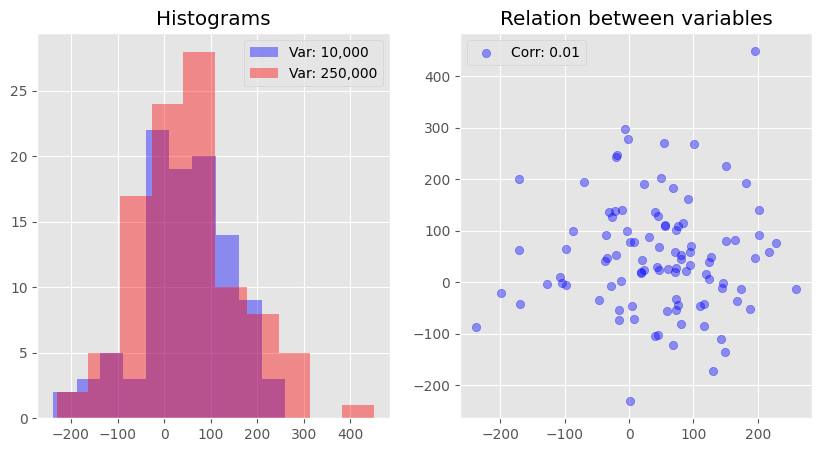

In [9]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))

ax[0].hist(x, color='blue', alpha=0.4, label='Var: 10,000')
ax[0].hist(y, color='red', alpha=0.4, label='Var: 250,000')
ax[0].legend()
ax[0].set_title('Histograms')

corr = np.corrcoef(x, y)[0, 1]
ax[1].scatter(x, y, color='blue', alpha=0.4, label=f'Corr: {np.round(corr, 2)}')

ax[1].legend()
ax[1].set_title('Relation between variables')

plt.show()

## Implicaciones: Varianza nula

Tengamos una variable a través del tiempo (como el caso de la acción de la clase pasada), pongamos una con varianza X y otra con varianza constante.


In [5]:
n = 250
tiempo = np.arange(n)


media = 120
desviacion = 30

serie_1 = np.random.normal(loc=media, scale=desviacion, size=n)
serie_2 = np.random.normal(loc=media, scale=0, size=n)

Text(0, 0.5, 'Precio')

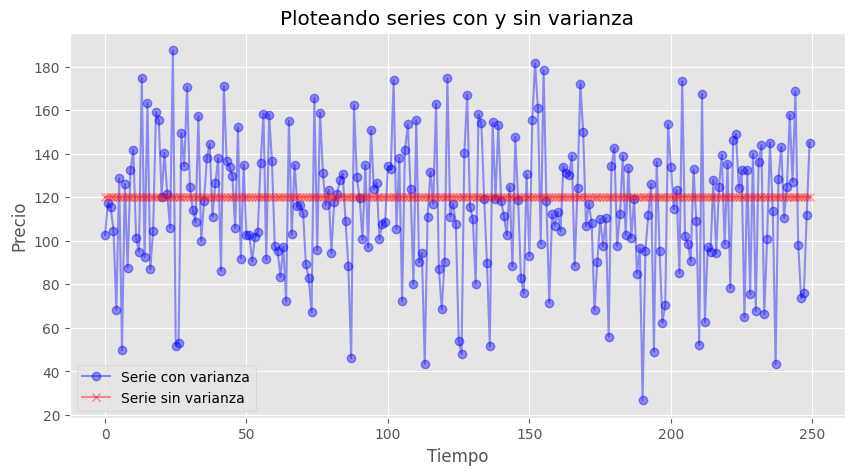

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(tiempo, serie_1, color='blue', marker='o', alpha=0.4, label='Serie con varianza')
ax.plot(tiempo, serie_2, color='red', marker='x', alpha=0.4, label='Serie sin varianza')
ax.legend()
ax.set_title('Ploteando series con y sin varianza')
ax.set_xlabel('Tiempo')
ax.set_ylabel('Precio')

Una variable sin varianza no es otra cosa que una constante. ¿De qué te va a servir una constante para explicar una variable que en efecto tiene variación?


In [11]:
path = '.'
file_name = 'actividad2a_6_1.csv'
df = pd.read_csv(os.path.join(path, file_name), index_col=0)


In [13]:
df

,x1,x2,index,y
0,0.784276,-2.043351,0,1
1,1.129094,-0.510168,1,1
2,-0.723555,-5.905577,2,0
3,-1.215612,23.317853,3,0
4,-1.050060,2.736050,4,0
...,...,...,...,...
95,-0.536866,0.910119,95,1
96,0.970332,7.455114,96,1
97,-0.333911,-0.956936,97,0
98,1.154292,-5.493340,98,1


Veamos ahora correlaciones del set que acabamos de leer.


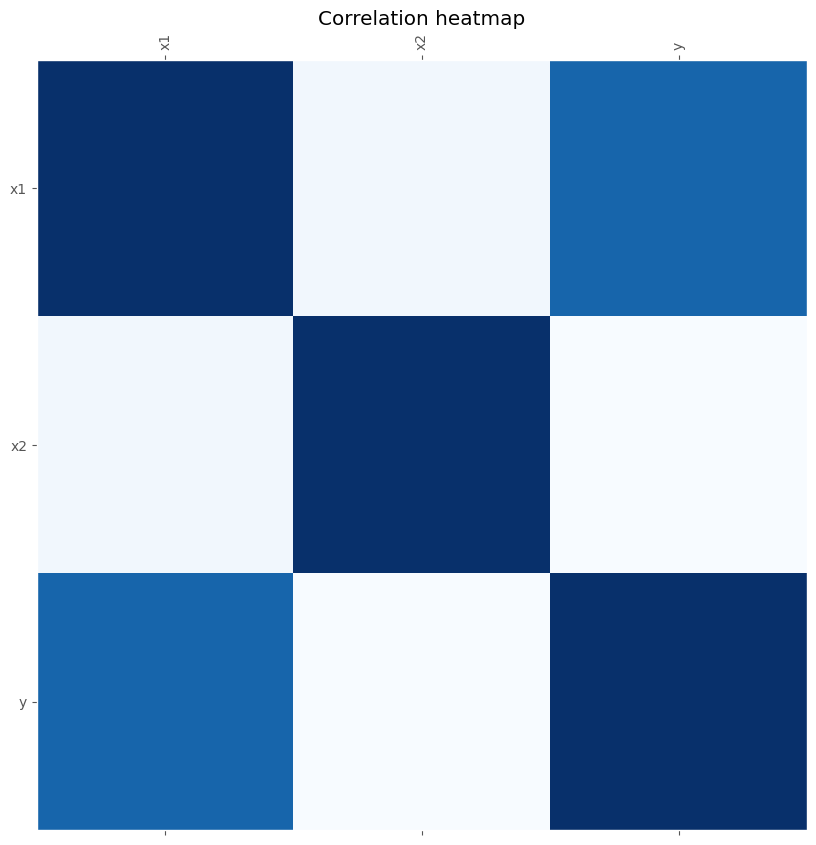

In [12]:
corr = df[['x1', 'x2', 'y']].select_dtypes(exclude=['object']).corr()

fig, ax = plt.subplots(figsize=(10, 10))
ax.matshow(corr, cmap='Blues')

ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)

ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns)

ax.set_title('Correlation heatmap')

ax.grid(False)



Observamos que una variable aleatoria ($x_2$) difícilmente tendrá relación con la variable objetivo ($y$). ¿Nos va a servir para identificar o predecir algo de $y$?


In [14]:
corr

,x1,x2,y
x1,1.000000,-0.007366,0.787961
x2,-0.007366,1.000000,-0.036763
y,0.787961,-0.036763,1.000000


## Actividad 1: Definiendo una metodología que nos permita separar entre variables


### Threshold por varianza

De estudios previos, se sabe que la varianza está definida como:

$$
s^2_n = \frac{1}{n} \sum_{i=1}^n (x_i - \bar{x})^2
$$

La intuición detrás de este método es escoger variables que tengan varianzas considerables pues se espera que exista mayor información entre las posibilidades de cambio que una varianza alta brinda.

A través de un análisis de varianzas escogeremos predictores.


In [18]:
# Definiendo variable para reproducibilidad.

prop_train = 0.8
file_name = 'actividad2b_6_1.csv'
df = pd.read_csv(file_name, index_col=0)
df.head()


train = df.sample(frac=prop_train, random_state=seed).copy()
test = df.loc[~df.index.isin(train.index)].copy()



# Definamos predictores 

predictores = [c for c in df if 'y' not in c]

Observemos las varianzas de nuestro set.


In [19]:
train[predictores].var().sort_values()

12    0.993589
11    0.998552
14    0.999424
8     1.000096
2     1.000882
5     1.001209
0     1.003294
7     1.007667
3     1.012599
13    1.015908
1     2.512108
6     2.544220
4     2.633701
9     2.722744
10    2.849758
dtype: float64

Definamos una serie de pasos entre los cuales recorreremos nuestro decisioner.


In [20]:
values = train[predictores].var()
min_v, max_v = values.min(), values.max()

step = (max_v - min_v) / len(values)

step

np.float64(0.12374455755500505)

In [21]:
np.arange(min_v, max_v + step, step)

array([0.99358947, 1.11733402, 1.24107858, 1.36482314, 1.4885677 ,
       1.61231225, 1.73605681, 1.85980137, 1.98354593, 2.10729048,
       2.23103504, 2.3547796 , 2.47852416, 2.60226872, 2.72601327,
       2.84975783])

In [22]:
def _get_steps(values):
    min_v, max_v = values.min(), values.max()
    step = (max_v - min_v) / len(values)

    return np.arange(min_v, max_v + step, step)


In [23]:
steps = _get_steps(values)
steps

array([0.99358947, 1.11733402, 1.24107858, 1.36482314, 1.4885677 ,
       1.61231225, 1.73605681, 1.85980137, 1.98354593, 2.10729048,
       2.23103504, 2.3547796 , 2.47852416, 2.60226872, 2.72601327,
       2.84975783])

In [26]:
for index, threshold in enumerate(steps):
    seleccionados = values.loc[values > threshold].index.tolist()
    print(seleccionados)

['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '13', '14']
['1', '4', '6', '9', '10']
['1', '4', '6', '9', '10']
['1', '4', '6', '9', '10']
['1', '4', '6', '9', '10']
['1', '4', '6', '9', '10']
['1', '4', '6', '9', '10']
['1', '4', '6', '9', '10']
['1', '4', '6', '9', '10']
['1', '4', '6', '9', '10']
['1', '4', '6', '9', '10']
['1', '4', '6', '9', '10']
['1', '4', '6', '9', '10']
['4', '9', '10']
['10']
[]


Vemos que se repiten


In [27]:
index_vistos = []
for index, threshold in enumerate(steps):
    seleccionados = values.loc[values > threshold].index.tolist()

    if seleccionados in index_vistos:
        continue
    index_vistos.append(seleccionados)
index_vistos

[['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '13', '14'],
 ['1', '4', '6', '9', '10'],
 ['4', '9', '10'],
 ['10'],
 []]

¿Qué tal si generamos un mismo modelo con cada uno de los sets y vemos cuál se comporta mejor?

El flujo sería entonces:

- Selección de variables.
- Generación de modelo.
  - Regresión logística.
- Modelo evalúa cada una de las selecciones.
  - Evaluaremos AUC (Area Under Curve).
- Comparamos y vemos cuál selección es la mejor.


In [30]:
modelo = LogisticRegression()
modelo.fit(train[predictores], train['y'])

scores = modelo.predict_proba(test[predictores])[:, 1]
scores

performance = roc_auc_score(y_score=scores,y_true=test['y'])
performance

0.8512271519038885

In [32]:
index_vistos = []
evaluaciones = {}
index = 0

for threshold in steps:
    seleccionados = values.loc[values > threshold].index.tolist()

    if len(seleccionados) == 0 or seleccionados in index_vistos:
        continue
    index_vistos.append(seleccionados)

    modelo = LogisticRegression()
    modelo.fit(train[seleccionados], train['y'])

    scores = modelo.predict_proba(test[seleccionados])[:, 1]

    performance = roc_auc_score(y_score=scores,y_true=test['y'])
    evaluaciones[index] = {'threshold': threshold, 'variables': seleccionados, 'performance': performance}
    index += 1
# Scoreando


# Evaluando


¿Qué rayos hicimos? Grafiquemos


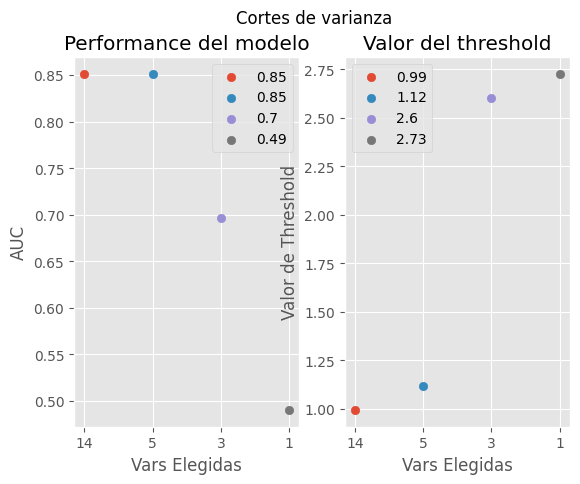

In [33]:
fig, (izg, der) = plt.subplots(nrows=1, ncols=2)

etiquetas =  []

for index, information in evaluaciones.items():
    seleccionados =  information['variables']
    threshold = information['threshold']
    performance = information['performance']

    variables = str(len(seleccionados))
    etiquetas.append(variables)

    label = f'{np.round(performance, 2)}'
    izg.scatter(index, performance, label=label)

    label = f'{np.round(threshold, 2)}'
    der.scatter(index, threshold, label=label)

izg.set_xticks(range(len(etiquetas)))
izg.set_xticklabels(etiquetas)

der.set_xticks(range(len(etiquetas)))
der.set_xticklabels(etiquetas)

izg.set_xlabel('Vars Elegidas')
izg.set_ylabel('AUC')
der.set_xlabel('Vars Elegidas')
der.set_ylabel('Valor de Threshold')

izg.legend()
der.legend()


fig.suptitle('Cortes de varianza')
izg.set_title('Performance del modelo')
der.set_title('Valor del threshold')
plt.show()

Hagamos lo propio con correlaciones.


Tenemos que remover la $y$, no podemos usar la respuesta para entrenar.


Obtengamos steps de correlación y repitamos:


### Conclusiones


### Bivariados

Tomemos las dos variables que selecciona la varianza y veamos ciertas cosas


#### Valor promedio de una variable según la respuesta


#### Scatter plot de una muestra separados por la variable de respuesta.


#### Valores por deciles


¿Qué hubiera pasado si usáramos una variable que casi no tiene relación con el response?


### Conclusiones
